<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Heterogeneoous_Quantum_System_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Subsystem Reference Data:


,name,role,native_strength,key_risk,evidence
0,Neutral atom Rydberg QPU,Main programmable entangling fabric,"Parallel CZ layers, long coherence, reconfigur...","Rydberg crosstalk, atom loss, optical alignmen...",Evered 2023; Manetsch 2025; Bluvstein 2024
1,Quantum photonic IC,Fusion and interconnect processor,"Time bin resources, PNR detection, fiber netwo...","Loss, phase drift, detector efficiency, multip...",Bartolucci 2023; Arrazola 2021; Aghaee Rad 2025
2,Microwave optical translators,Bridge between optical and superconducting dom...,"LiNbO3 EO paths, optomechanics, Rydberg ensembles","Added noise, low overall efficiency, pump leakage",Holzgrafe 2020; Sahu 2022; Borowka 2024
3,Superconducting cat memory,Noise biased logical storage and refresh opera...,Passive bit flip suppression and repetition ca...,Bias degradation during gates and parity checks,Lescanne 2020; Guillaud 2019; Puri 2020
4,Transmon ancilla layer,"Parity checks, SNAP orchestration, and system ...",Microwave nonlinear control and circuit QED in...,"Leakage, spectral crowding, ancilla induced de...",Rigetti 2010; Chow 2013; Larsen 2015
5,Cryogenic control and RAM,"Local microcode, waveform cache, timing, and a...",Cryo CMOS memory with SFQ timing primitives,"Thermal load, quasiparticles, electromagnetic ...",Underwood 2024; Mukhanov 2011; Herr 2011



Interface Reference Data:


,interface,efficiency,added_noise_photons,latency_us,risk_score
0,Atom to atom Rydberg gate,0.995,0.00,0.50,2
1,Atom to photonic chip link,0.700,0.05,5.00,3
2,Photonic fusion fabric,0.750,0.05,1.00,3
3,Microwave to optical translator,0.100,0.80,10.00,4
4,Cat memory to transmon parity,0.980,0.02,2.00,3
5,Cryogenic control to qubit plane,0.990,0.00,0.05,3



Compliance Evaluation Data:


,interface,efficiency_ok,noise_ok,risk_ok,stage_gate_pass
0,Atom to atom Rydberg gate,True,True,True,True
1,Atom to photonic chip link,True,True,True,True
2,Photonic fusion fabric,True,True,True,True
3,Microwave to optical translator,True,True,False,False
4,Cat memory to transmon parity,True,True,True,True
5,Cryogenic control to qubit plane,True,True,True,True



Interfaces requiring focused mitigation:
* Microwave to optical translator


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

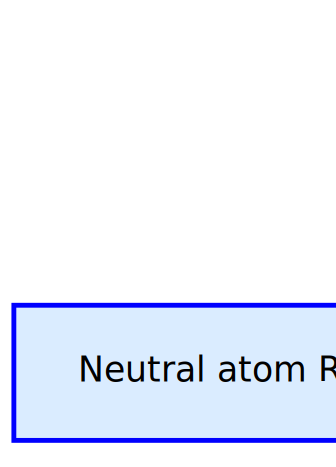

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

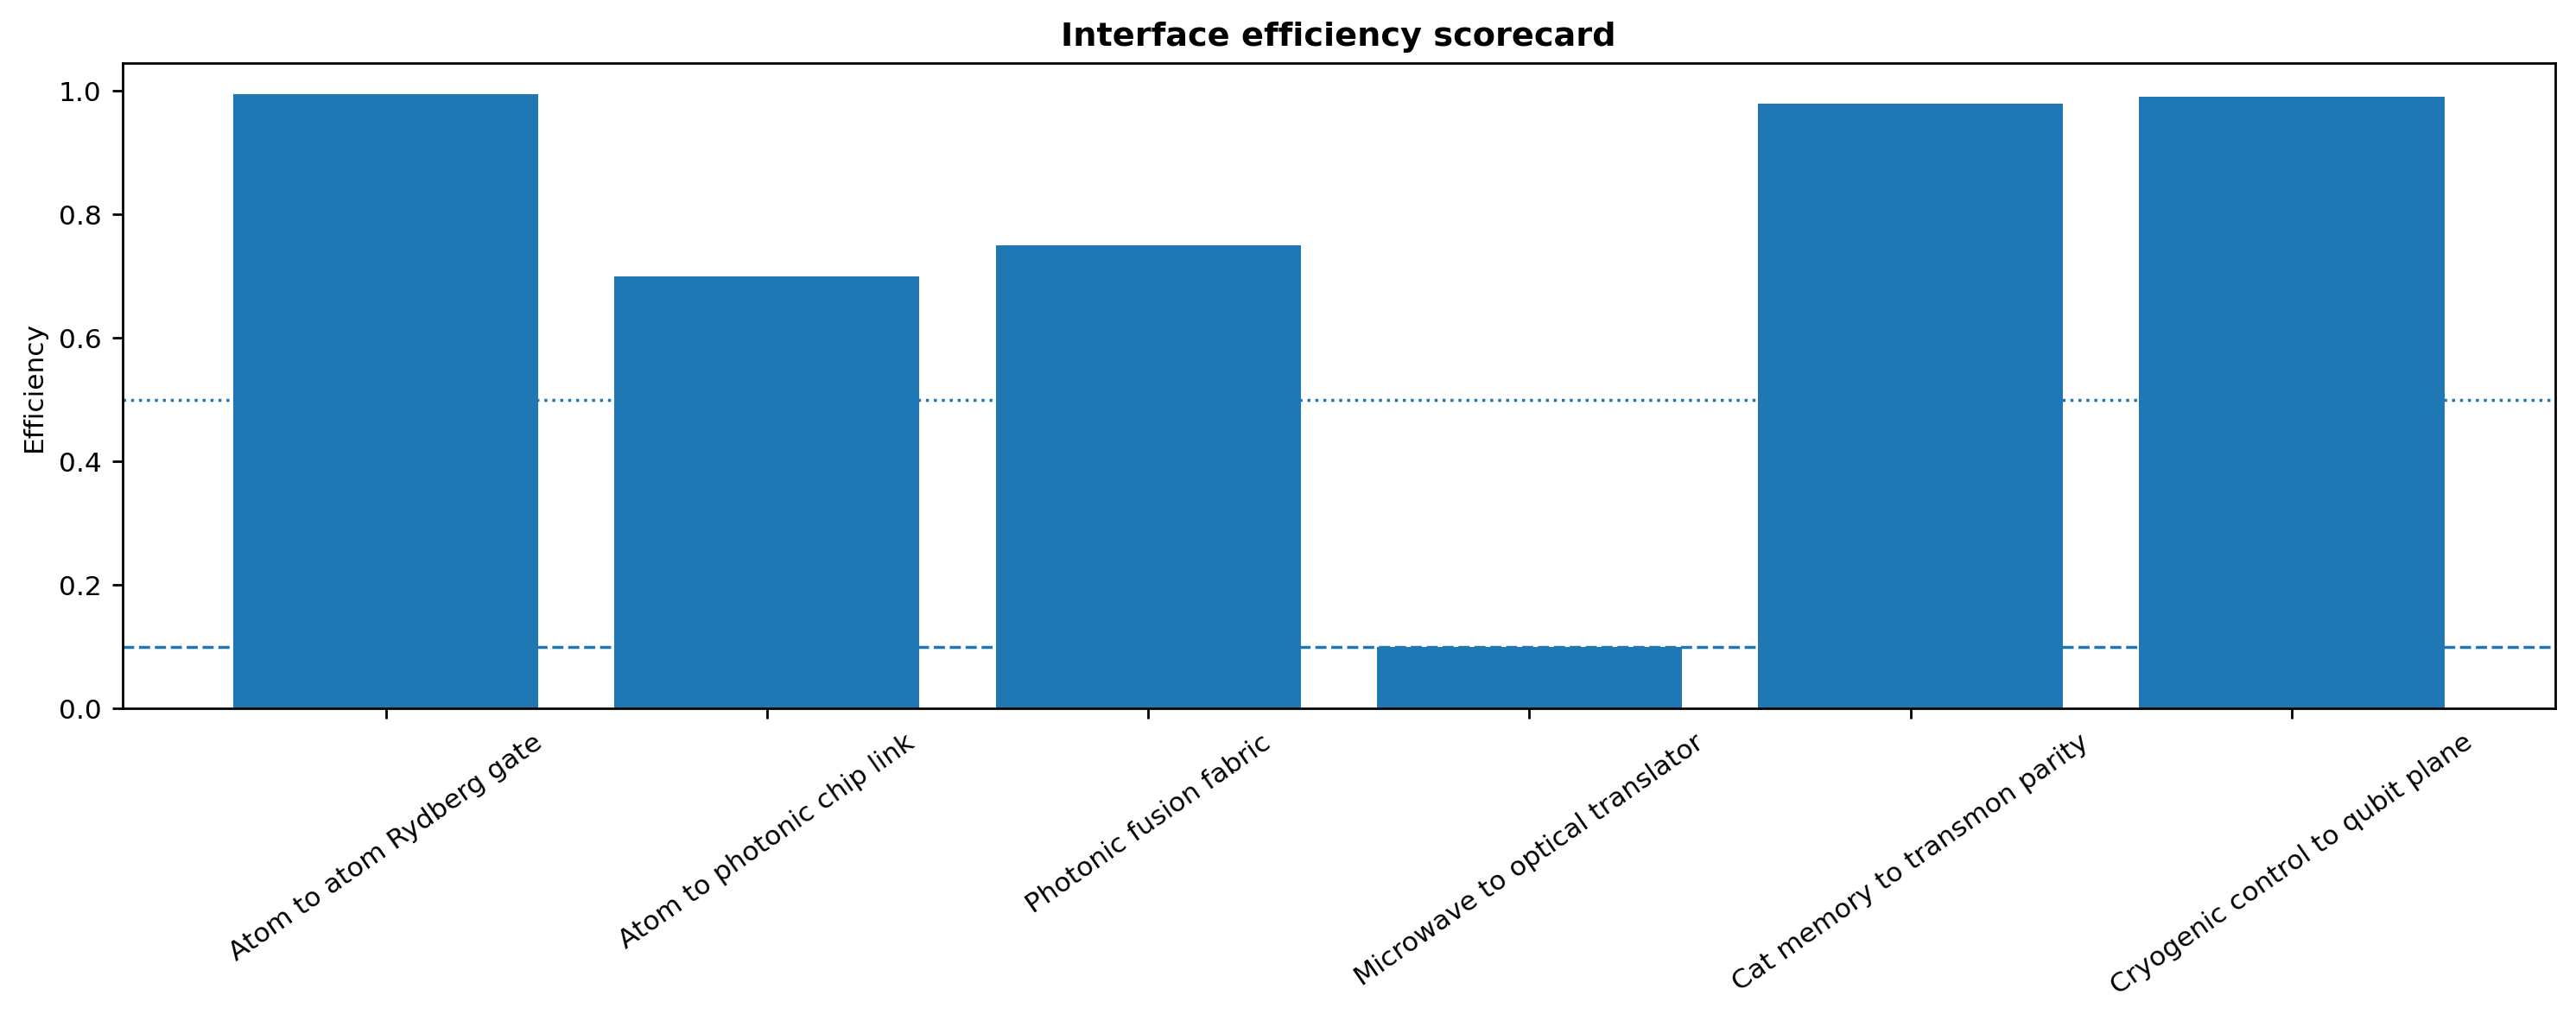

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

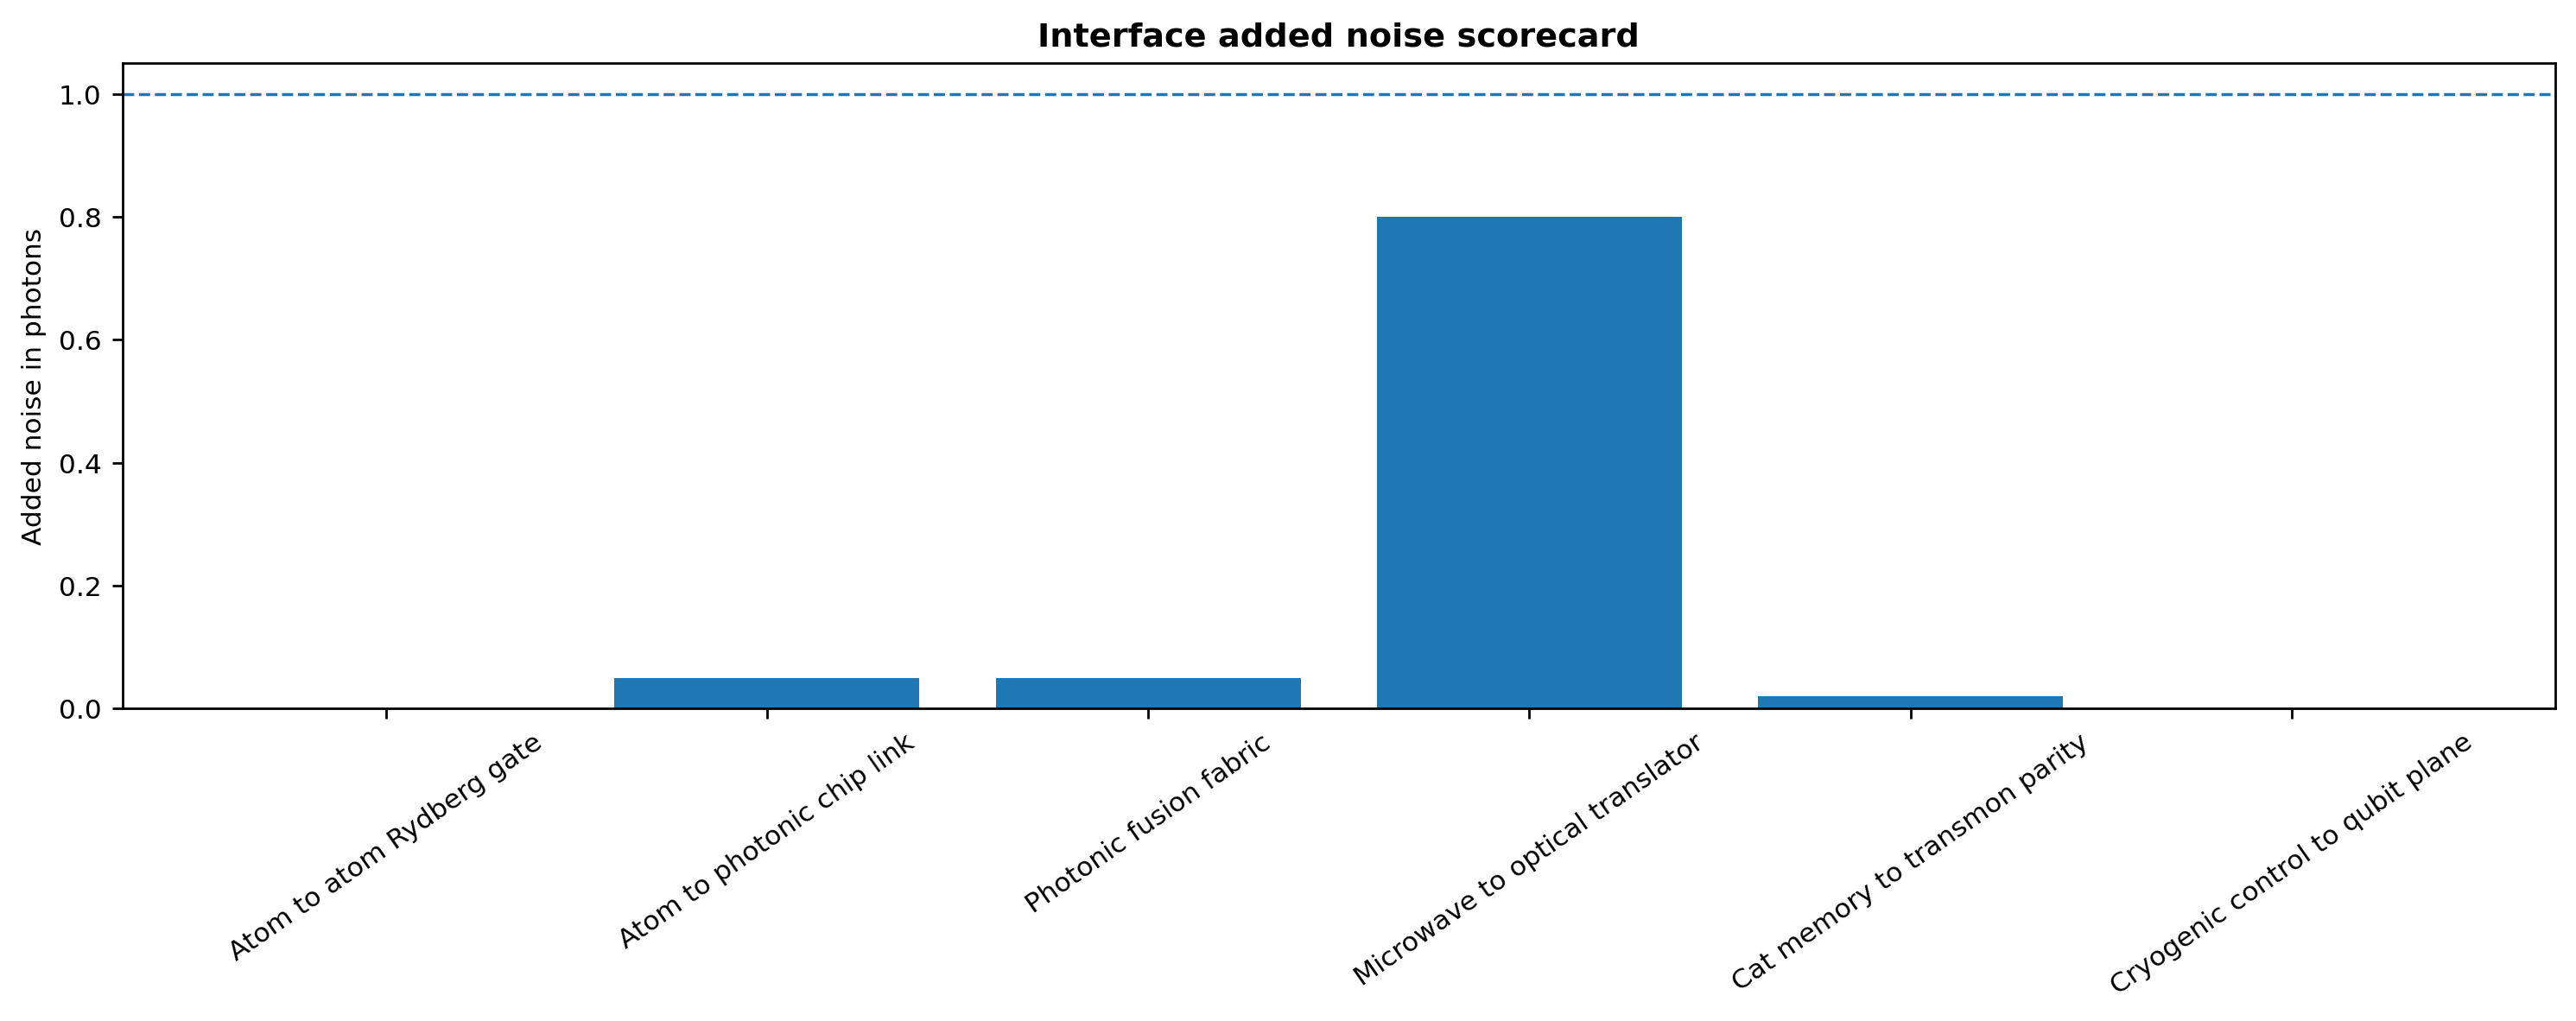

In [ ]:
"""Control knobs and analytical functions for the heterogeneous architecture analysis."""

from __future__ import annotations

from dataclasses import dataclass
from typing import Iterable, List

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Visualization parameters ensuring adherence to typographic requirements
plt.rcParams["figure.dpi"] = 250
plt.rcParams["font.size"] = 9
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["font.sans-serif"] = ["IBM Plex Sans", "DejaVu Sans", "Arial", "sans-serif"]
plt.rcParams["font.weight"] = "normal"
plt.rcParams["axes.titleweight"] = "semibold"

# Global control variables for system evaluation
ARCHITECT_NAME = "Onri Jay Benally"
FIGURE_WIDTH = 12.0
FIGURE_HEIGHT = 7.5
INTERNAL_EFFICIENCY_TARGET = 0.10
ASPIRATIONAL_EFFICIENCY_TARGET = 0.50
ADDED_NOISE_TARGET_PHOTONS = 1.0
MAX_ALLOWED_STAGE_RISK = 3
RANDOM_SEED = 7

# Control knob to manage file exports
DOWNLOAD_OUTPUTS_AS_PNG = True

np.random.seed(RANDOM_SEED)

@dataclass(frozen=True)
class Subsystem:
    """Describe a subsystem within the heterogeneous quantum computing architecture."""

    name: str
    role: str
    native_strength: str
    key_risk: str
    evidence: str

@dataclass(frozen=True)
class InterfaceMetric:
    """Store a measurable interface target for domain transitions."""

    interface: str
    efficiency: float
    added_noise_photons: float
    latency_us: float
    risk_score: int

# System definitions
SUBSYSTEMS: List[Subsystem] = [
    Subsystem(
        name="Neutral atom Rydberg QPU",
        role="Main programmable entangling fabric",
        native_strength="Parallel CZ layers, long coherence, reconfigurable layouts",
        key_risk="Rydberg crosstalk, atom loss, optical alignment drift",
        evidence="Evered 2023; Manetsch 2025; Bluvstein 2024",
    ),
    Subsystem(
        name="Quantum photonic IC",
        role="Fusion and interconnect processor",
        native_strength="Time bin resources, PNR detection, fiber networking",
        key_risk="Loss, phase drift, detector efficiency, multiplexing overhead",
        evidence="Bartolucci 2023; Arrazola 2021; Aghaee Rad 2025",
    ),
    Subsystem(
        name="Microwave optical translators",
        role="Bridge between optical and superconducting domains",
        native_strength="LiNbO3 EO paths, optomechanics, Rydberg ensembles",
        key_risk="Added noise, low overall efficiency, pump leakage",
        evidence="Holzgrafe 2020; Sahu 2022; Borowka 2024",
    ),
    Subsystem(
        name="Superconducting cat memory",
        role="Noise biased logical storage and refresh operations",
        native_strength="Passive bit flip suppression and repetition cat compatibility",
        key_risk="Bias degradation during gates and parity checks",
        evidence="Lescanne 2020; Guillaud 2019; Puri 2020",
    ),
    Subsystem(
        name="Transmon ancilla layer",
        role="Parity checks, SNAP orchestration, and system readout",
        native_strength="Microwave nonlinear control and circuit QED integration",
        key_risk="Leakage, spectral crowding, ancilla induced dephasing",
        evidence="Rigetti 2010; Chow 2013; Larsen 2015",
    ),
    Subsystem(
        name="Cryogenic control and RAM",
        role="Local microcode, waveform cache, timing, and active feedback",
        native_strength="Cryo CMOS memory with SFQ timing primitives",
        key_risk="Thermal load, quasiparticles, electromagnetic coupling",
        evidence="Underwood 2024; Mukhanov 2011; Herr 2011",
    ),
]

INTERFACES: List[InterfaceMetric] = [
    InterfaceMetric("Atom to atom Rydberg gate", 0.995, 0.00, 0.5, 2),
    InterfaceMetric("Atom to photonic chip link", 0.70, 0.05, 5.0, 3),
    InterfaceMetric("Photonic fusion fabric", 0.75, 0.05, 1.0, 3),
    InterfaceMetric("Microwave to optical translator", 0.10, 0.80, 10.0, 4),
    InterfaceMetric("Cat memory to transmon parity", 0.98, 0.02, 2.0, 3),
    InterfaceMetric("Cryogenic control to qubit plane", 0.99, 0.00, 0.05, 3),
]

def evaluate_interfaces(metrics: Iterable[InterfaceMetric]) -> pd.DataFrame:
    """Return a target compliance table for evaluated interface metrics.

    Args:
        metrics: Interface metrics requiring evaluation.

    Returns:
        A pandas DataFrame containing verification flags for target checks.
    """
    records = []
    for metric in metrics:
        efficiency_ok = metric.efficiency >= INTERNAL_EFFICIENCY_TARGET
        noise_ok = metric.added_noise_photons <= ADDED_NOISE_TARGET_PHOTONS
        risk_ok = metric.risk_score <= MAX_ALLOWED_STAGE_RISK
        records.append(
            {
                "interface": metric.interface,
                "efficiency_ok": efficiency_ok,
                "noise_ok": noise_ok,
                "risk_ok": risk_ok,
                "stage_gate_pass": efficiency_ok and noise_ok and risk_ok,
            }
        )
    return pd.DataFrame(records)

def build_architecture_graph() -> graphviz.Digraph:
    """Construct a directed graph modeling architecture data flow using the DOT language.

    Returns:
        A Graphviz Digraph object defining hardware domains as colorized nodes.
    """
    dot = graphviz.Digraph(comment=f"Heterogeneous Quantum Architecture, architect: {ARCHITECT_NAME}")

    dot.attr(dpi="250", fontname="IBM Plex Sans", rankdir="TB")
    dot.attr(
        "node",
        shape="box",
        style="filled",
        fontname="IBM Plex Sans",
        margin="0.2",
        fontsize="10",
        color="#0000ff",
        penwidth="1.4"
    )
    dot.attr(
        "edge",
        fontname="IBM Plex Sans",
        fontsize="8",
        color="#0000ff",
        penwidth="1.2"
    )

    nodes_with_colors = {
        "Neutral atom Rydberg QPU": "#daecff",
        "Quantum photonic IC": "#e8e0ff",
        "Microwave optical translators": "#ffeed4",
        "Superconducting cat memory": "#dbf4de",
        "Transmon ancilla layer": "#ffe0e7",
        "Cryogenic control and RAM": "#e8e8e8",
    }

    for name, color in nodes_with_colors.items():
        dot.node(name, name, fillcolor=color)

    edges = [
        ("Neutral atom Rydberg QPU", "Quantum photonic IC", "atom photon link"),
        ("Quantum photonic IC", "Microwave optical translators", "optical mode"),
        ("Microwave optical translators", "Superconducting cat memory", "microwave mode"),
        ("Superconducting cat memory", "Transmon ancilla layer", "parity and SNAP"),
        ("Cryogenic control and RAM", "Transmon ancilla layer", "waveforms"),
        ("Cryogenic control and RAM", "Neutral atom Rydberg QPU", "schedule"),
        ("Cryogenic control and RAM", "Quantum photonic IC", "feedforward"),
    ]

    for source, destination, label in edges:
        dot.edge(source, destination, label=label)

    return dot

def plot_interface_efficiency(frame: pd.DataFrame) -> None:
    """Render a comprehensive bar chart mapping interface efficiencies.

    Args:
        frame: A DataFrame containing designated interface and efficiency columns.
    """
    _, axis = plt.subplots(figsize=(FIGURE_WIDTH, 4.8))
    axis.bar(frame["interface"], frame["efficiency"])
    axis.axhline(INTERNAL_EFFICIENCY_TARGET, linestyle="--", linewidth=1.0)
    axis.axhline(ASPIRATIONAL_EFFICIENCY_TARGET, linestyle=":", linewidth=1.0)
    axis.set_ylabel("Efficiency")
    axis.set_title("Interface efficiency scorecard")
    axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()

    if DOWNLOAD_OUTPUTS_AS_PNG:
        file_name = "interface_efficiency_scorecard.png"
        plt.savefig(file_name, bbox_inches="tight")
        if IN_COLAB:
            files.download(file_name)

    plt.show()

def plot_added_noise(frame: pd.DataFrame) -> None:
    """Render a bar chart illustrating the calculated added noise budgets.

    Args:
        frame: A DataFrame containing designated interface and added noise columns.
    """
    _, axis = plt.subplots(figsize=(FIGURE_WIDTH, 4.8))
    axis.bar(frame["interface"], frame["added_noise_photons"])
    axis.axhline(ADDED_NOISE_TARGET_PHOTONS, linestyle="--", linewidth=1.0)
    axis.set_ylabel("Added noise in photons")
    axis.set_title("Interface added noise scorecard")
    axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()

    if DOWNLOAD_OUTPUTS_AS_PNG:
        file_name = "interface_added_noise_scorecard.png"
        plt.savefig(file_name, bbox_inches="tight")
        if IN_COLAB:
            files.download(file_name)

    plt.show()

# Execution phase integrating all analytical components
subsystem_frame = pd.DataFrame([item.__dict__ for item in SUBSYSTEMS])
interface_frame = pd.DataFrame([item.__dict__ for item in INTERFACES])

print("Subsystem Reference Data:")
display(subsystem_frame)

print("\nInterface Reference Data:")
display(interface_frame)

compliance_frame = evaluate_interfaces(INTERFACES)
print("\nCompliance Evaluation Data:")
display(compliance_frame)

failing = compliance_frame.loc[~compliance_frame["stage_gate_pass"], "interface"]
print("\nInterfaces requiring focused mitigation:")
for name in failing:
    print(f"* {name}")

architecture_graph = build_architecture_graph()

if DOWNLOAD_OUTPUTS_AS_PNG:
    architecture_graph.render("heterogeneous_architecture_graph", format="png", cleanup=True)
    if IN_COLAB:
        files.download("heterogeneous_architecture_graph.png")

display(architecture_graph)
plot_interface_efficiency(interface_frame)
plot_added_noise(interface_frame)